In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import *

base_path = '/home/shiftpub/Dynamic_AMM/inf_step_exp/dp_approach/results/Jun19/steps_100'

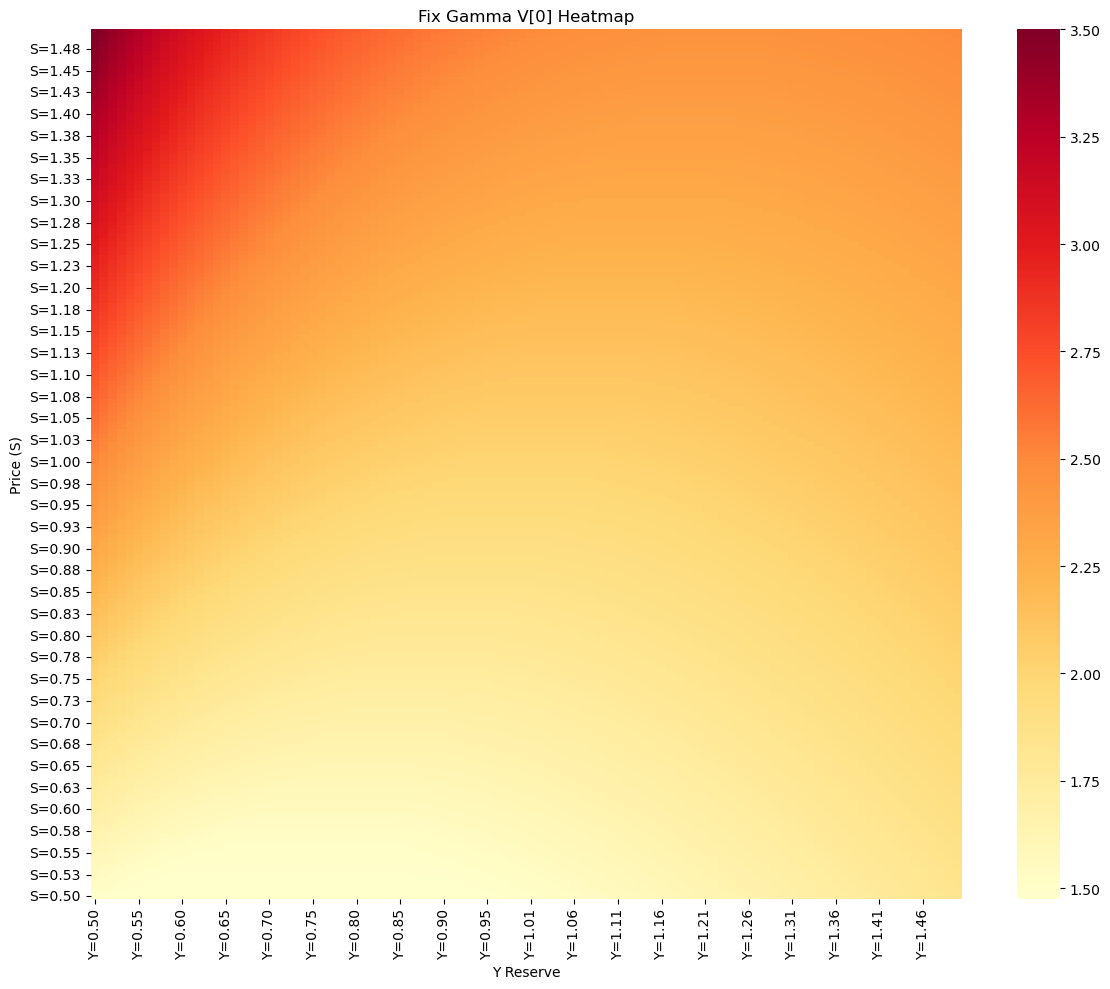

In [13]:
V_fix_gamma = pd.read_csv(f'{base_path}/V_fix_gamma.csv')
V_fix_gamma.index = [f"S={S_grid[j]:.2f}" for j in range(nS)]
V_fix_gamma.columns = [f"Y={Y_grid[k]:.2f}" for k in range(nY)]

plt.figure(figsize=(12, 10))
sns.heatmap(V_fix_gamma, cmap='YlOrRd', fmt='.2f', 
            xticklabels=5, yticklabels=5)  # Show every 5th label to avoid overcrowding
plt.title('Fix Gamma V[0] Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')
plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()


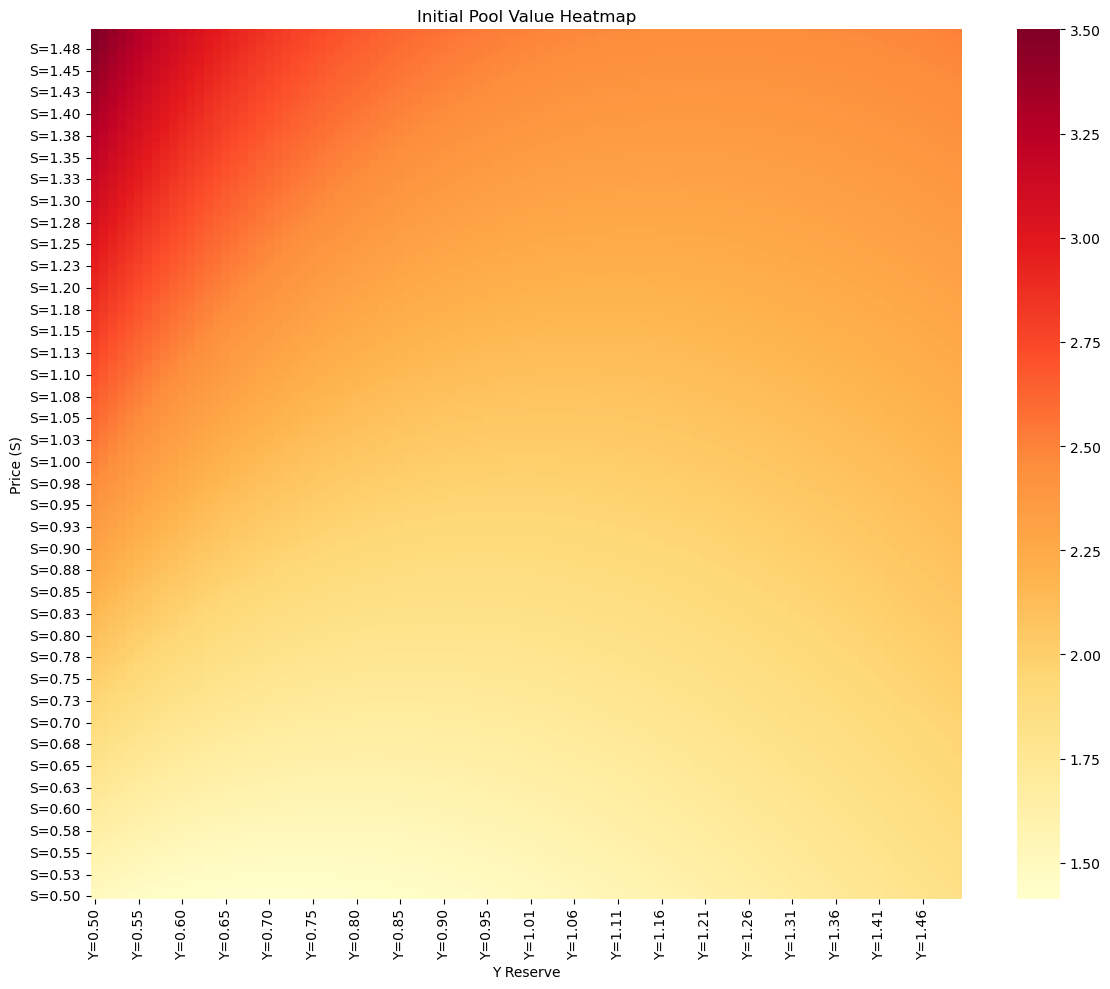

In [14]:
pv0 = pd.read_csv(f'{base_path}/initial_pool_value.csv')
pv0.index = [f"S={S_grid[j]:.2f}" for j in range(nS)]
pv0.columns = [f"Y={Y_grid[k]:.2f}" for k in range(nY)]
plt.figure(figsize=(12, 10))
sns.heatmap(pv0, cmap='YlOrRd', fmt='.2f', 
            xticklabels=5, yticklabels=5)  # Show every 5th label to avoid overcrowding
plt.title('Initial Pool Value Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')
plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()

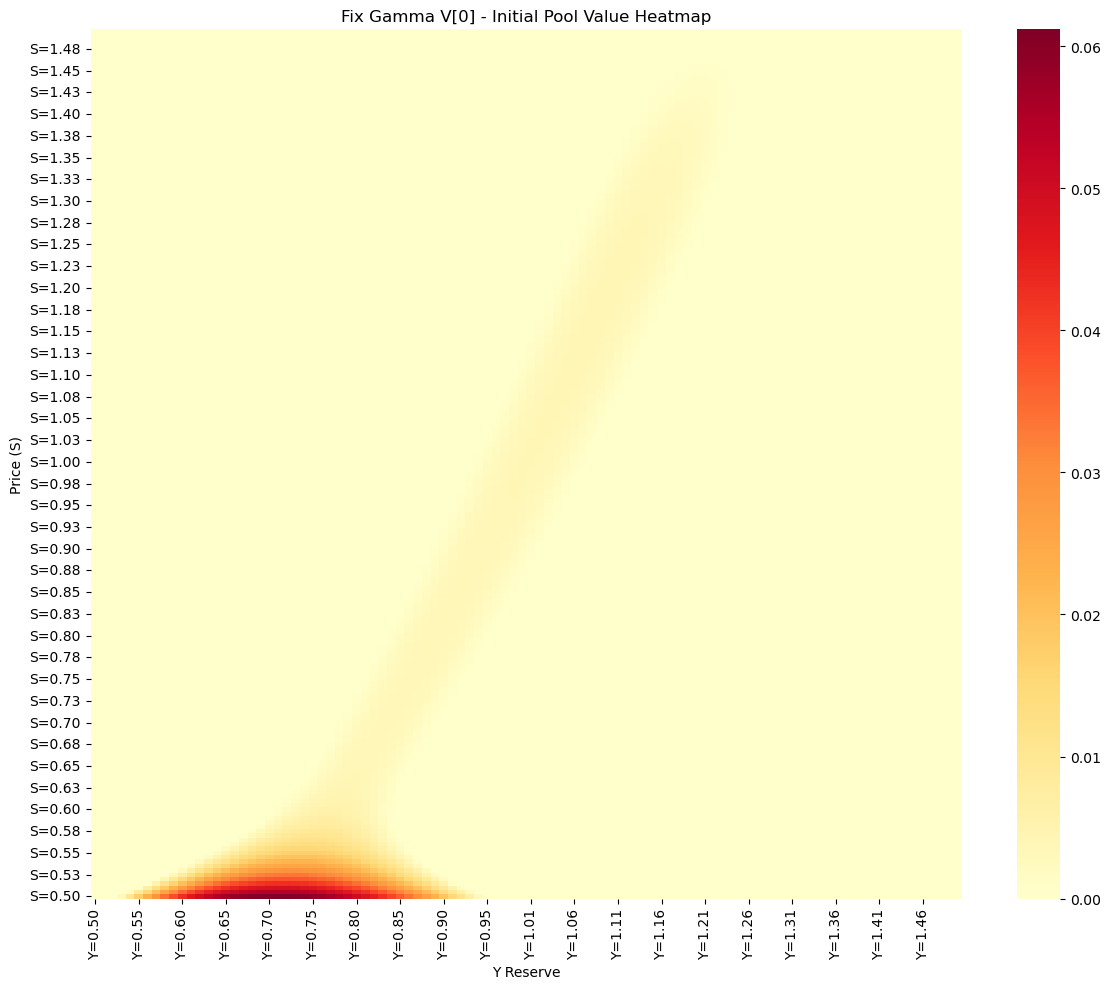

In [15]:

plt.figure(figsize=(12, 10))
sns.heatmap(V_fix_gamma - pv0, cmap='YlOrRd', fmt='.2f',
            xticklabels=5, yticklabels=5)  # Show every 5th label to avoid overcrowding

plt.title('Fix Gamma V[0] - Initial Pool Value Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')
plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()

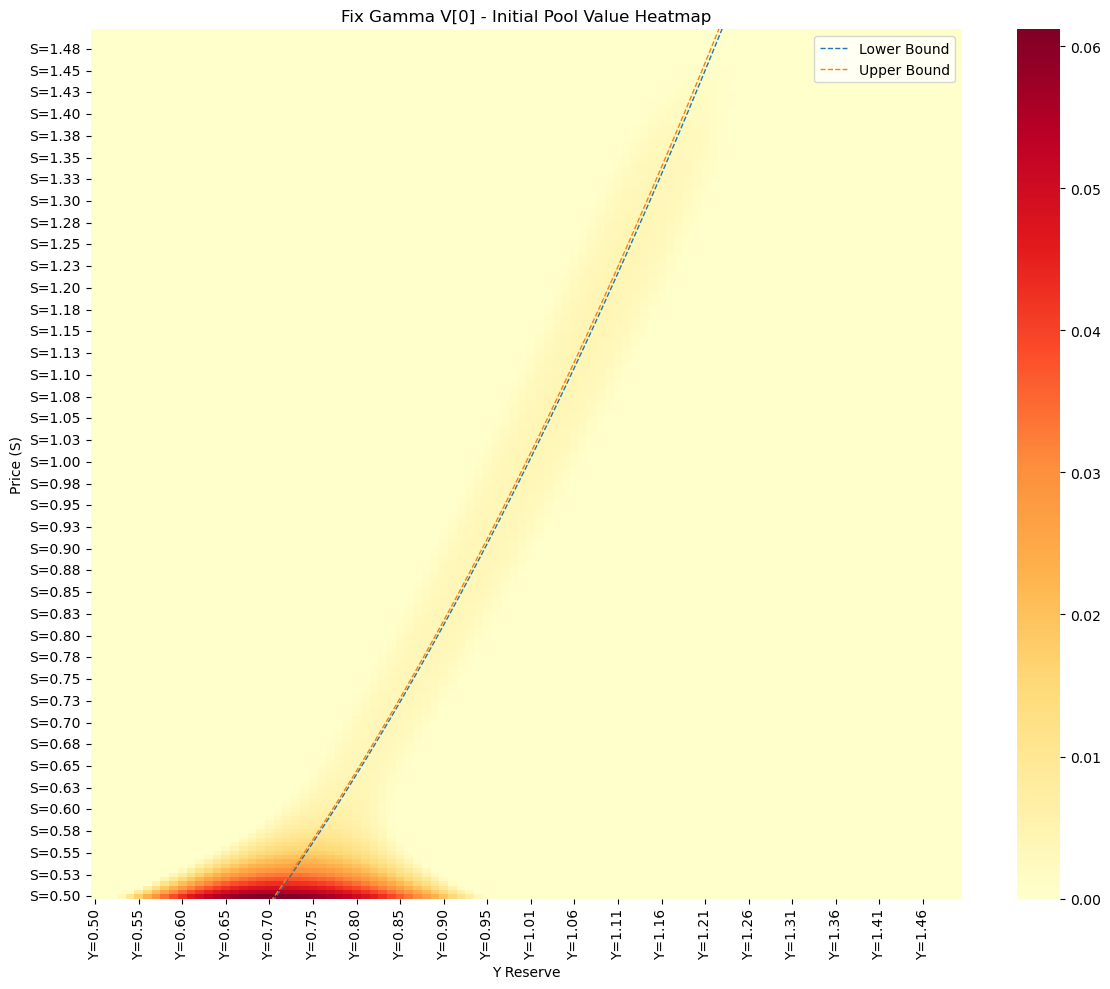

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Alternative: Even more direct approach if S_grid is linearly spaced
plt.figure(figsize=(12, 10))
ax = sns.heatmap(V_fix_gamma - pv0, cmap='YlOrRd', fmt='.2f',
                 xticklabels=5, yticklabels=5)
plt.title('Fix Gamma V[0] - Initial Pool Value Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')

# If S_grid is linearly spaced, you can use this simpler approach
S_min, S_max = S_grid.min(), S_grid.max()
S_range = S_max - S_min

y_positions = np.arange(len(Y_grid)) + 0.5
lower_positions = []
upper_positions = []

for y in Y_grid:
    lower_bound = y**2 * (1-gamma)
    upper_bound = y**2 / (1-gamma)
    
    # Convert S values to normalized positions (0 to len(S_grid))
    lower_norm = (lower_bound - S_min) / S_range * len(S_grid)
    upper_norm = (upper_bound - S_min) / S_range * len(S_grid)
    
    lower_positions.append(lower_norm)
    upper_positions.append(upper_norm)

# Plot the boundary lines
ax.plot(y_positions, lower_positions, '--', linewidth=1, label='Lower Bound')
ax.plot(y_positions, upper_positions, '--', linewidth=1, label='Upper Bound')
ax.legend()

plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()



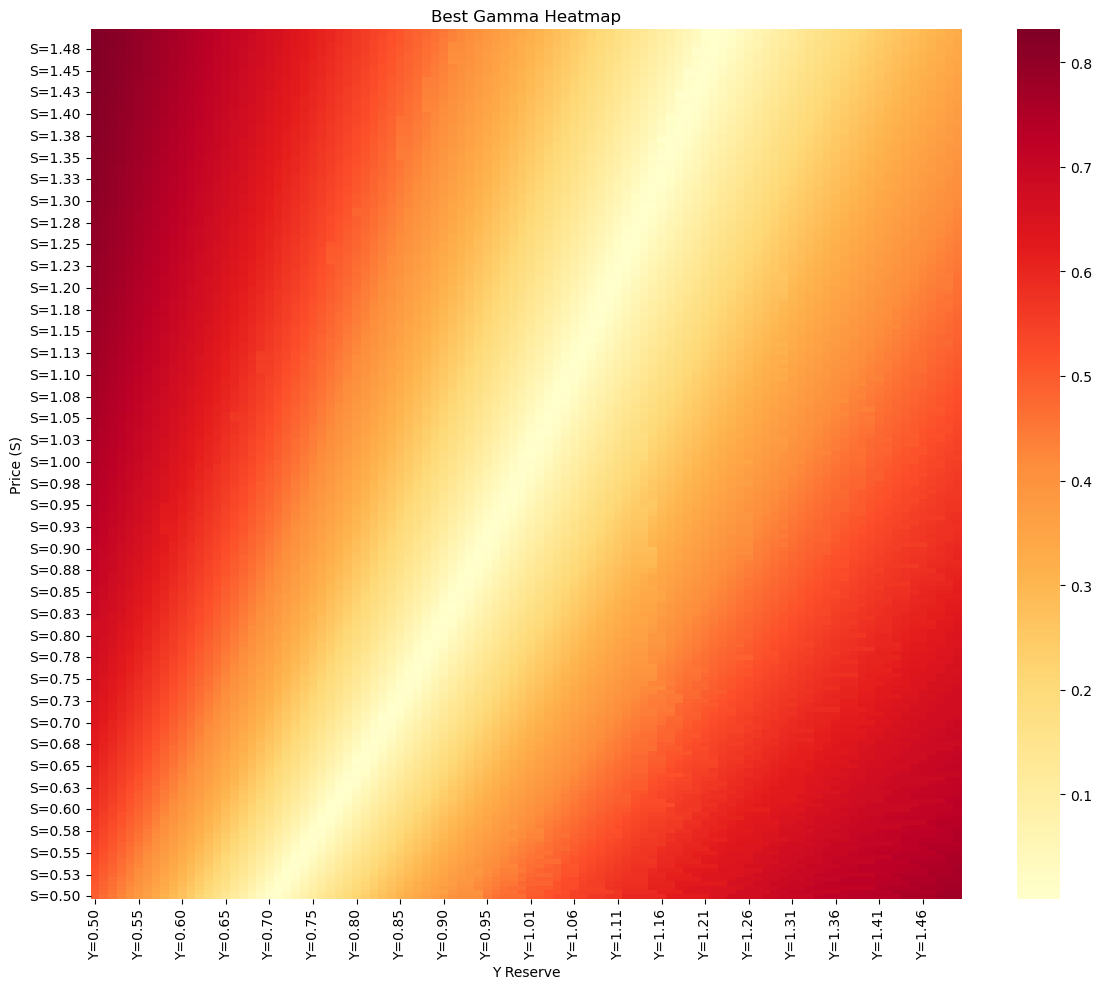

In [6]:
best_gamma = pd.read_csv(f'{base_path}/best_gamma.csv')
best_gamma.index = [f"S={S_grid[j]:.2f}" for j in range(nS)]
best_gamma.columns = [f"Y={Y_grid[k]:.2f}" for k in range(nY)]

plt.figure(figsize=(12, 10))
sns.heatmap(best_gamma, cmap='YlOrRd', fmt='.2f', 
            xticklabels=5, yticklabels=5)  # Show every 5th label to avoid overcrowding
plt.title('Best Gamma Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')
plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()

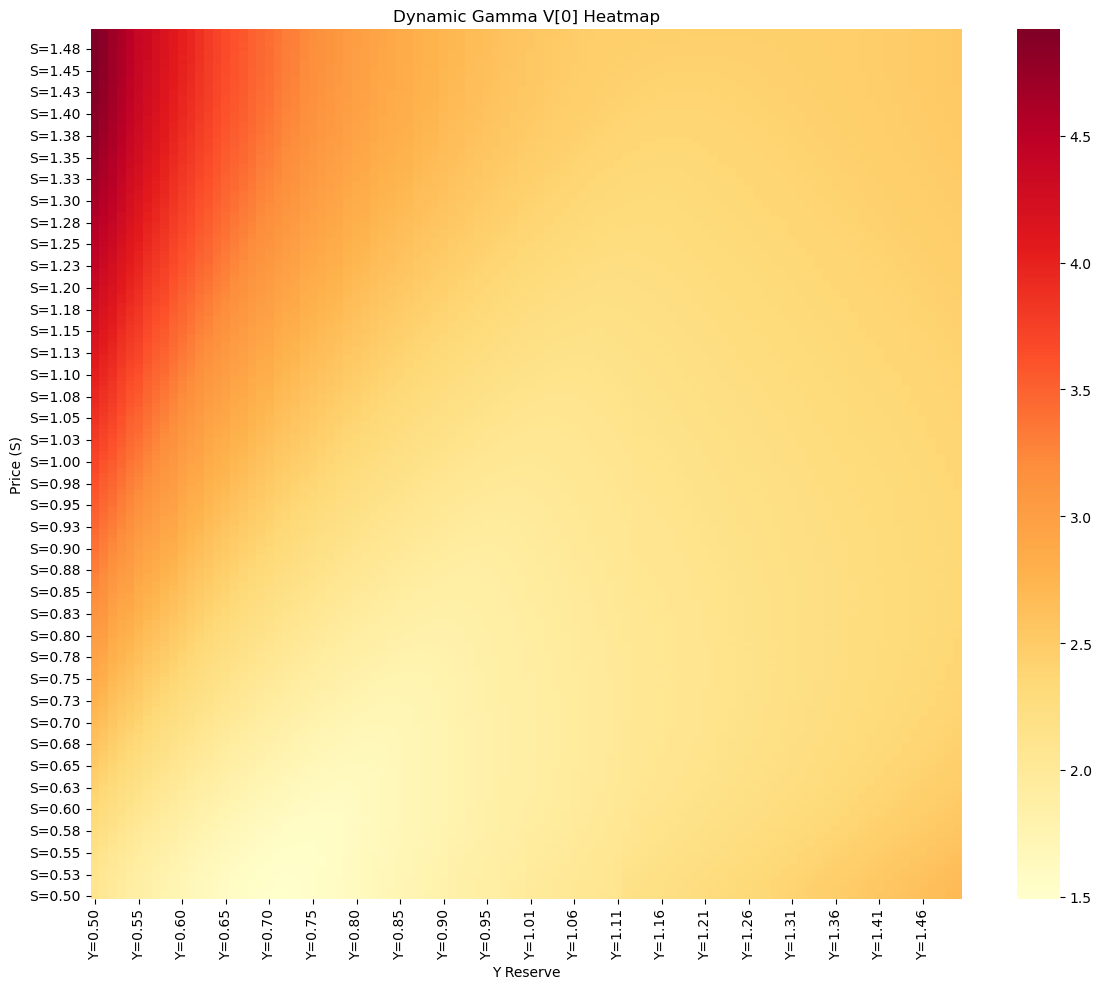

In [7]:
V_dynamic_gamma = pd.read_csv(f'{base_path}/V_dynamic_gamma.csv')
V_dynamic_gamma.index = [f"S={S_grid[j]:.2f}" for j in range(nS)]
V_dynamic_gamma.columns = [f"Y={Y_grid[k]:.2f}" for k in range(nY)]
plt.figure(figsize=(12, 10))
sns.heatmap(V_dynamic_gamma, cmap='YlOrRd', fmt='.2f', 
            xticklabels=5, yticklabels=5)  # Show every 5th label to avoid overcrowding
plt.title('Dynamic Gamma V[0] Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')
plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()

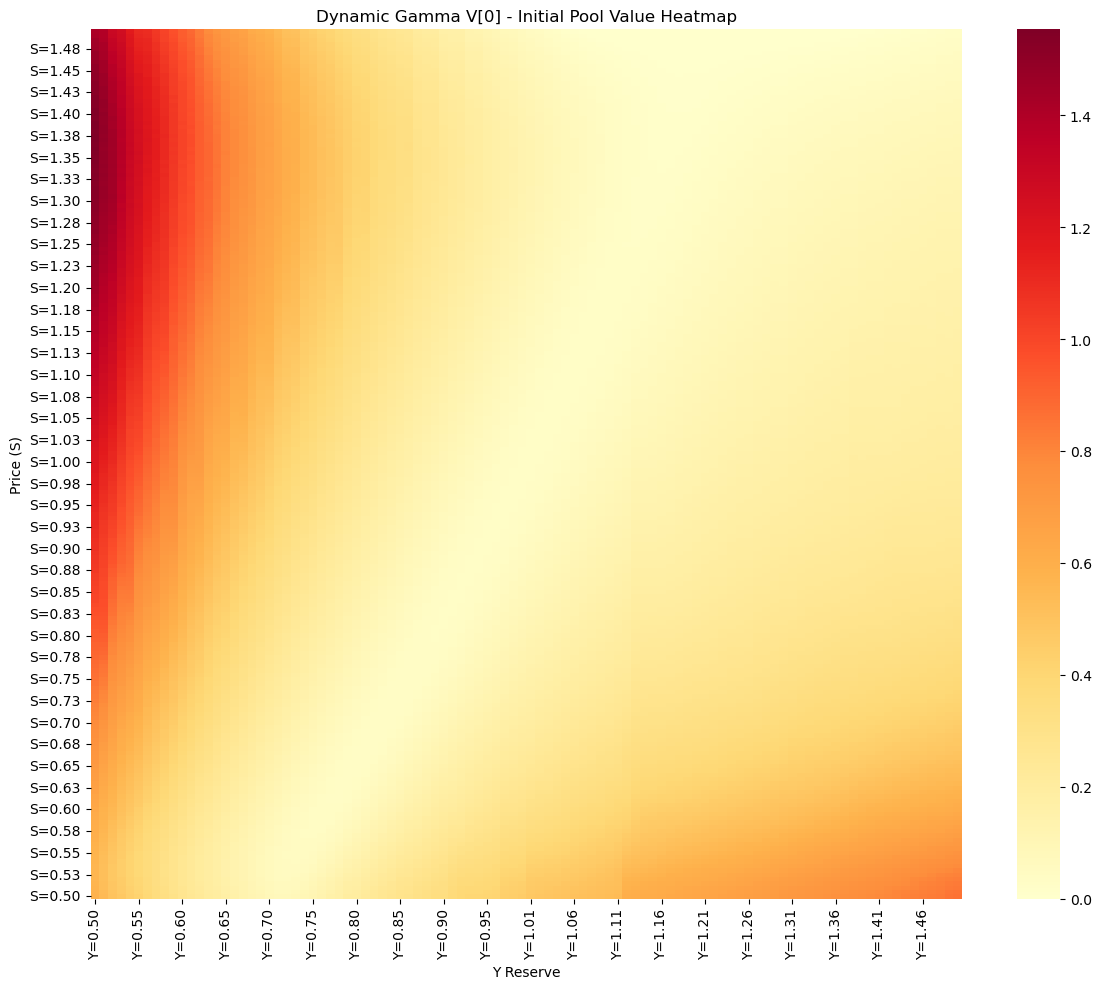

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(V_dynamic_gamma - pv0, cmap='YlOrRd', fmt='.2f',
            xticklabels=5, yticklabels=5)  # Show every 5th label to avoid overcrowding
plt.title('Dynamic Gamma V[0] - Initial Pool Value Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')
plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()

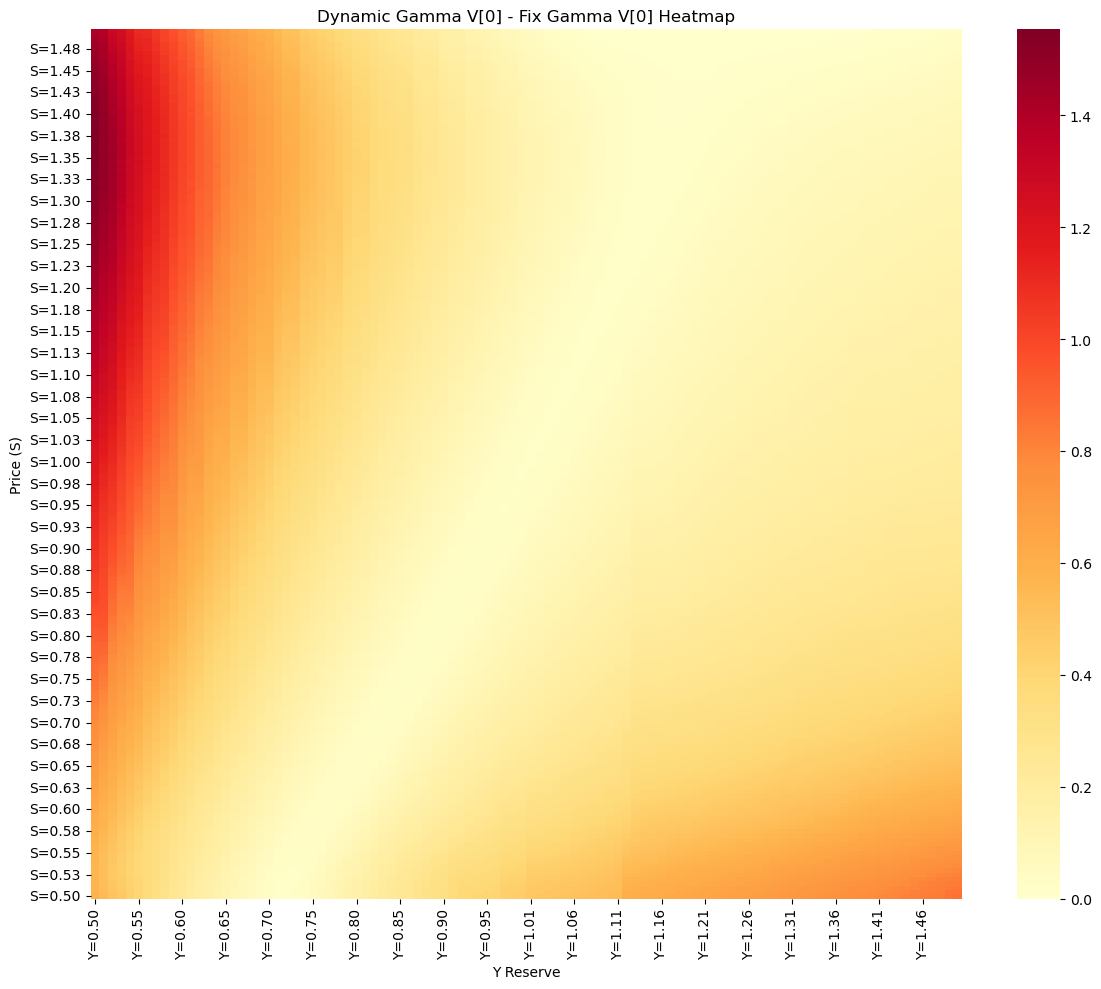

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(V_dynamic_gamma - V_fix_gamma, cmap='YlOrRd', fmt='.2f',
            xticklabels=5, yticklabels=5)  # Show every 5th label to avoid overcrowding
plt.title('Dynamic Gamma V[0] - Fix Gamma V[0] Heatmap')
plt.xlabel('Y Reserve')
plt.ylabel('Price (S)')
plt.gca().invert_yaxis()  # Invert y-axis
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

steps = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
results = []
for step in steps:
    V_fix_gamma = pd.read_csv(f'results/steps_{step}/V_fix_gamma.csv')
    results.append({
        'step': step,
        'V1' : V_fix_gamma.iloc[0, 0],
        'V2' : V_fix_gamma.iloc[0, -1],
        'V3' : V_fix_gamma.iloc[-1, 0],
        'V4' : V_fix_gamma.iloc[-1, -1]
    })
results_df = pd.DataFrame(results)
print(results_df.to_markdown())

|    |       step |       V1 |       V2 |       V3 |       V4 |
|---:|-----------:|---------:|---------:|---------:|---------:|
|  0 |    100     |  1.5     |  1.83333 |  3.5     |  2.5     |
|  1 |    200     |  1.90411 |  1.90467 |  2.3     |  2.2     |
|  2 |    500     |  1.9751  |  1.97566 |  2.3     |  2.2     |
|  3 |   1000     |  2.05253 |  2.05309 |  2.3     |  2.2     |
|  4 |   2000     |  2.13554 |  2.1361  |  2.3     |  2.2     |
|  5 |   5000     |  2.19963 |  2.20019 |  2.3     |  2.2     |
|  6 |  10000     |  2.24502 |  2.24558 |  2.3     |  2.24496 |
|  7 |  20000     |  2.33573 |  2.33629 |  2.33631 |  2.33567 |
|  8 |  50000     |  2.60786 |  2.60843 |  2.60844 |  2.6078  |
|  9 | 100000     |  3.06143 |  3.06199 |  3.062   |  3.06137 |
| 10 | 200000     |  3.96855 |  3.96911 |  3.96913 |  3.96849 |
| 11 | 500000     |  6.68991 |  6.69048 |  6.69049 |  6.68985 |
| 12 |      1e+06 | 11.2255  | 11.2261  | 11.2261  | 11.2255  |
